In [9]:
# import pyranges as pr
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import re

# import plotly.graph_objects as go

import matplotlib.patches as patches

In [3]:
%%time 
# === Load and filter GTF ===
gpath = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)

exons = gtf[gtf['Feature'] == 'exon']
print(f"{exons.shape=}")
exons.head()

exons.shape=(1586950, 27)
CPU times: user 8.11 s, sys: 1.32 s, total: 9.43 s
Wall time: 19 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
2,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NaN,NaN,1.0,ENSE00003753029,1.0,NaN,NaN,ENSP00000484918.1,NaN
10,GL000194.1,ENSEMBL,exon,114985,115018,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,1.0,ENSE00002299440,2.0,NaN,NaN,ENSP00000483280.1,NaN
11,GL000194.1,ENSEMBL,exon,112791,112850,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,2.0,ENSE00003739295,1.0,NaN,NaN,ENSP00000483280.1,NaN
12,GL000194.1,ENSEMBL,exon,53589,55676,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,3.0,ENSE00003723764,1.0,NaN,NaN,ENSP00000483280.1,NaN
22,GL000194.1,ENSEMBL,exon,114985,115055,.,-,.,ENSG00000274847,1,...,MAFIP-201,1.0,NaN,1.0,ENSE00003736481,1.0,HGNC:31102,NaN,ENSP00000478910.1,NaN


In [199]:
# gtf[gtf['transcript_name'] == 'FLNA-212']

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
3285360,chrX,HAVANA,transcript,154352537,154353456,.,-,.,ENSG00000196924,19,...,FLNA-212,2.0,OTTHUMT00000316553.1,NaN,NaN,NaN,HGNC:3754,OTTHUMG00000022712.33,NaN,NaN
3285361,chrX,HAVANA,exon,154353295,154353456,.,-,.,ENSG00000196924,19,...,FLNA-212,2.0,OTTHUMT00000316553.1,1.0,ENSE00001919571,1.0,HGNC:3754,OTTHUMG00000022712.33,NaN,NaN
3285362,chrX,HAVANA,exon,154352537,154353204,.,-,.,ENSG00000196924,19,...,FLNA-212,2.0,OTTHUMT00000316553.1,2.0,ENSE00001924636,1.0,HGNC:3754,OTTHUMG00000022712.33,NaN,NaN


In [12]:
gtf['Feature'].value_counts()

Feature
exon              1586950
CDS                876982
UTR                376798
transcript         226005
start_codon         97000
stop_codon          90690
gene                38606
Selenocysteine        130
Name: count, dtype: int64

In [212]:
query = [
    'TEAD1-203',
    'TEAD1-206',
    
    'CD63-201',
    'CD63-214',
    
    'ARHGAP29-201',
    'ARHGAP29-202',
    
    'FLNA-201',
    'FLNA-202',
    'FLNA-212',
    
    'RACK1-210',
    'RACK1-227',
]

tmp = gtf[gtf['transcript_name'].isin(query)].copy()
tmp = tmp[tmp['Feature'].isin(['transcript'])]
display(tmp)

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
228743,chr1,HAVANA,transcript,94168904,94237584,.,-,.,ENSG00000137962,13,...,ARHGAP29-201,1.0,OTTHUMT00000029376.3,NaN,NaN,NaN,HGNC:30207,OTTHUMG00000010643.4,ENSP00000260526.6,CCDS748.1
228805,chr1,HAVANA,transcript,94201894,94237633,.,-,.,ENSG00000137962,13,...,ARHGAP29-202,1.0,OTTHUMT00000029381.1,NaN,NaN,NaN,HGNC:30207,OTTHUMG00000010643.4,ENSP00000359237.3,NaN
1058090,chr5,HAVANA,transcript,181236896,181243906,.,-,.,ENSG00000204628,12,...,RACK1-227,1.0,OTTHUMT00000372943.3,NaN,NaN,NaN,HGNC:4399,OTTHUMG00000163380.15,ENSP00000426909.1,CCDS34324.1
1058132,chr5,HAVANA,transcript,181236925,181243889,.,-,.,ENSG00000204628,12,...,RACK1-210,1.0,OTTHUMT00000373294.1,NaN,NaN,NaN,HGNC:4399,OTTHUMG00000163380.15,ENSP00000422198.1,NaN
1757562,chr11,HAVANA,transcript,12674420,12944737,.,+,.,ENSG00000187079,20,...,TEAD1-206,1.0,OTTHUMT00000386822.3,NaN,NaN,NaN,HGNC:11714,OTTHUMG00000165878.8,ENSP00000435233.2,CCDS7810.2
1757660,chr11,HAVANA,transcript,12879442,12944483,.,+,.,ENSG00000187079,20,...,TEAD1-203,1.0,OTTHUMT00000387220.1,NaN,NaN,NaN,HGNC:11714,OTTHUMG00000165878.8,ENSP00000435393.1,NaN
2073257,chr12,HAVANA,transcript,55725322,55729009,.,-,.,ENSG00000135404,12,...,CD63-201,1.0,OTTHUMT00000409235.1,NaN,NaN,NaN,HGNC:1692,OTTHUMG00000170454.5,ENSP00000257857.4,CCDS8890.1
2073354,chr12,HAVANA,transcript,55725469,55728482,.,-,.,ENSG00000135404,12,...,CD63-214,1.0,OTTHUMT00000409233.1,NaN,NaN,NaN,HGNC:1692,OTTHUMG00000170454.5,ENSP00000449337.1,CCDS8890.1
3284801,chrX,HAVANA,transcript,154348528,154371283,.,-,.,ENSG00000196924,19,...,FLNA-201,1.0,OTTHUMT00000058941.2,NaN,NaN,NaN,HGNC:3754,OTTHUMG00000022712.33,ENSP00000353467.4,CCDS44021.1
3285198,chrX,HAVANA,transcript,154348530,154374634,.,-,.,ENSG00000196924,19,...,FLNA-202,1.0,OTTHUMT00000058942.7,NaN,NaN,NaN,HGNC:3754,OTTHUMG00000022712.33,ENSP00000358866.3,CCDS48194.1


In [209]:
%%time

query = [
    # 'TEAD1-203',
    # 'TEAD1-206',
    
    # 'CD63-201',
    # 'CD63-214',
    
    # 'ARHGAP29-201',
    # 'ARHGAP29-202',
    
    # 'FLNA-201',
    # 'FLNA-202',
    # 'FLNA-212',
    
    'RACK1-210',
    'RACK1-227',
]

columns = [
    'transcript_name',
    'Chromosome',
    'Start', 
    'End',
    'Feature',
    'exon_id',
    'exon_version',
]

df = gtf[gtf['transcript_name'].isin(query)].copy()

# df.tail()
# df = df[df['Feature'] == 'exon']
df = df[df['Feature'].isin(['CDS', 'UTR'])]
df = df[columns]
print(f"{df.shape=}")

# Sort by transcript and exon number
df = df.sort_values(["transcript_name", "Start"])

print(df.head(10).to_string(index=False))

df.shape=(20, 7)
transcript_name Chromosome     Start       End Feature         exon_id  exon_version
      RACK1-210       chr5 181236925 181237042     UTR ENSE00002034638           1.0
      RACK1-210       chr5 181237608 181237719     UTR ENSE00003633005           1.0
      RACK1-210       chr5 181238098 181238239     UTR ENSE00003601546           1.0
      RACK1-210       chr5 181239066 181239177     UTR ENSE00003646006           1.0
      RACK1-210       chr5 181239486 181239582     UTR ENSE00003683879           1.0
      RACK1-210       chr5 181241491 181241576     UTR ENSE00003627526           1.0
      RACK1-210       chr5 181241576 181241639     CDS ENSE00003627526           1.0
      RACK1-210       chr5 181242169 181242345     CDS ENSE00003467948           1.0
      RACK1-210       chr5 181243691 181243800     CDS ENSE00002066089           1.0
      RACK1-210       chr5 181243800 181243889     UTR ENSE00002066089           1.0
CPU times: user 57.5 ms, sys: 69 μs, total: 57.6

In [210]:
# -----------------------------
# 2️⃣ Collapse intervals to remove gaps between exons
# -----------------------------
gap = 20

intervals = df[['Chromosome','Start','End']].sort_values('Start').reset_index(drop=True)
merged_rows = []
current_start = None
current_end = None
chrom = None

for _, row in intervals.iterrows():
    if current_start is None:
        chrom = row['Chromosome']
        current_start = row['Start']
        current_end = row['End']
        continue

    if row['Start'] <= current_end:
        current_end = max(current_end, row['End'])
    else:
        merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
        current_start = row['Start']
        current_end = row['End']

merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
merged_df = pd.DataFrame(merged_rows)
merged_df = merged_df.sort_values('Start').reset_index(drop=True)
merged_df['Length'] = merged_df['End'] - merged_df['Start']
merged_df['collapsed_start'] = merged_df['Length'].shift(fill_value=0).cumsum() + gap * merged_df.index
merged_df['collapsed_end'] = merged_df['collapsed_start'] + merged_df['Length']

# Map exons to collapsed coordinates
def map_exon(row, merged_df):
    hit = merged_df[(merged_df['Start'] <= row['Start']) & (merged_df['End'] >= row['End'])]
    if hit.empty:
        raise ValueError(f"Exon not contained in any merged interval: {row}")
    hit = hit.iloc[0]
    offset = row['Start'] - hit['Start']
    return pd.Series({
        'collapsed_start': hit['collapsed_start'] + offset,
        'collapsed_end': hit['collapsed_start'] + offset + (row['End'] - row['Start'])
    })

df[['collapsed_start', 'collapsed_end']] = df.apply(map_exon, axis=1, merged_df=merged_df)

display(df)



### THIS CODE WORKED NICELY FOR 3' UTRs
# -----------------------------
# 3️⃣ Truncate long 3' UTRs and insert gap
# -----------------------------
utr_trunc_len = 1000
utr_gap = 300
min_utr_length = 2000  # only truncate if last 3' UTR is longer than this

plot_rows = []

# Get collapsed 3' UTR lengths for each transcript
utr_df = df[df['Feature']=='UTR']
last_utrs = utr_df.groupby('transcript_name').apply(lambda x: x.iloc[-1])
utr_lengths = last_utrs['collapsed_end'] - last_utrs['collapsed_start']

# Identify shortest last 3' UTR length
shortest_utr_len = utr_lengths.min()

# Compute remaining length for each transcript (after truncated block + gap)
remaining_lens = utr_lengths - shortest_utr_len  # may be 0 for shortest transcript

# Determine where truncated block + gap ends (same for all transcripts)
trunc_end = last_utrs['collapsed_start'].min() + utr_trunc_len
gap_end = trunc_end + utr_gap

for tx in df['transcript_name'].unique():
    tdf = df[df['transcript_name']==tx].sort_values('collapsed_start')
    
    # Keep all rows except last 3' UTR
    last_utr_row = tdf[tdf['Feature']=='UTR'].iloc[-1]
    non_last = tdf[tdf.index != last_utr_row.name]
    plot_rows.extend(non_last.to_dict('records'))
    
    if utr_lengths[tx] > min_utr_length:
        # 1️⃣ first truncated UTR (1000 nt)
        seg1 = last_utr_row.copy()
        seg1['collapsed_start'] = trunc_end - utr_trunc_len
        seg1['collapsed_end'] = trunc_end
        plot_rows.append(seg1)

        # 2️⃣ gap
        gap_row = last_utr_row.copy()
        gap_row['Feature'] = 'gap'
        gap_row['Start'] = None
        gap_row['End'] = None
        gap_row['exon_id'] = None
        gap_row['exon_version'] = None
        gap_row['collapsed_start'] = trunc_end
        gap_row['collapsed_end'] = gap_end
        plot_rows.append(gap_row)

        # 3️⃣ remaining 3' UTR
        seg3 = last_utr_row.copy()
        seg3['collapsed_start'] = gap_end
        seg3['collapsed_end'] = gap_end + utr_trunc_len + remaining_lens[tx]
        plot_rows.append(seg3)
    else:
        # keep last UTR as-is
        plot_rows.append(last_utr_row.to_dict())

plot_df = pd.DataFrame(plot_rows)

display(plot_df)

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
1058152,RACK1-210,chr5,181236925,181237042,UTR,ENSE00002034638,1.0,29,146
1058151,RACK1-210,chr5,181237608,181237719,UTR,ENSE00003633005,1.0,166,277
1058150,RACK1-210,chr5,181238098,181238239,UTR,ENSE00003601546,1.0,297,438
1058149,RACK1-210,chr5,181239066,181239177,UTR,ENSE00003646006,1.0,458,569
1058148,RACK1-210,chr5,181239486,181239582,UTR,ENSE00003683879,1.0,589,685
1058147,RACK1-210,chr5,181241491,181241576,UTR,ENSE00003627526,1.0,705,790
1058139,RACK1-210,chr5,181241576,181241639,CDS,ENSE00003627526,1.0,790,853
1058137,RACK1-210,chr5,181242169,181242345,CDS,ENSE00003467948,1.0,873,1049
1058134,RACK1-210,chr5,181243691,181243800,CDS,ENSE00002066089,1.0,1069,1178
1058146,RACK1-210,chr5,181243800,181243889,UTR,ENSE00002066089,1.0,1178,1267


/tmp/ipykernel_3625323/2721089188.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_utrs = utr_df.groupby('transcript_name').apply(lambda x: x.iloc[-1])


,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
0,RACK1-210,chr5,181236925,181237042,UTR,ENSE00002034638,1.0,29,146
1,RACK1-210,chr5,181237608,181237719,UTR,ENSE00003633005,1.0,166,277
2,RACK1-210,chr5,181238098,181238239,UTR,ENSE00003601546,1.0,297,438
3,RACK1-210,chr5,181239066,181239177,UTR,ENSE00003646006,1.0,458,569
4,RACK1-210,chr5,181239486,181239582,UTR,ENSE00003683879,1.0,589,685
5,RACK1-210,chr5,181241491,181241576,UTR,ENSE00003627526,1.0,705,790
6,RACK1-210,chr5,181241576,181241639,CDS,ENSE00003627526,1.0,790,853
7,RACK1-210,chr5,181242169,181242345,CDS,ENSE00003467948,1.0,873,1049
8,RACK1-210,chr5,181243691,181243800,CDS,ENSE00002066089,1.0,1069,1178
9,RACK1-210,chr5,181243800,181243889,UTR,ENSE00002066089,1.0,1178,1267


In [192]:
# # For ARHGAP29
# new_start = 3667

# # Index of the first row
# first_row_idx = 0

# # Set first row collapsed_start and collapsed_end
# plot_df.at[first_row_idx, 'collapsed_start'] = new_start
# plot_df.at[first_row_idx, 'collapsed_end'] = plot_df.at[first_row_idx, 'collapsed_end']  # keep original end

# # Shift all rows so that first row starts at 0
# plot_df['collapsed_start'] = plot_df['collapsed_start'] - new_start
# plot_df['collapsed_end'] = plot_df['collapsed_end'] - new_start

# plot_df.head()

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
0,ARHGAP29-201,chr1,94168904,94173871,UTR,ENSE00001180201,9.0,0,1300
1,ARHGAP29-201,chr1,94173871,94174749,CDS,ENSE00001180201,9.0,1300,2178
2,ARHGAP29-201,chr1,94177611,94177720,CDS,ENSE00000932136,1.0,2198,2307
3,ARHGAP29-201,chr1,94177851,94178167,CDS,ENSE00003467206,1.0,2327,2643
4,ARHGAP29-201,chr1,94179724,94179957,CDS,ENSE00003595265,1.0,2663,2896


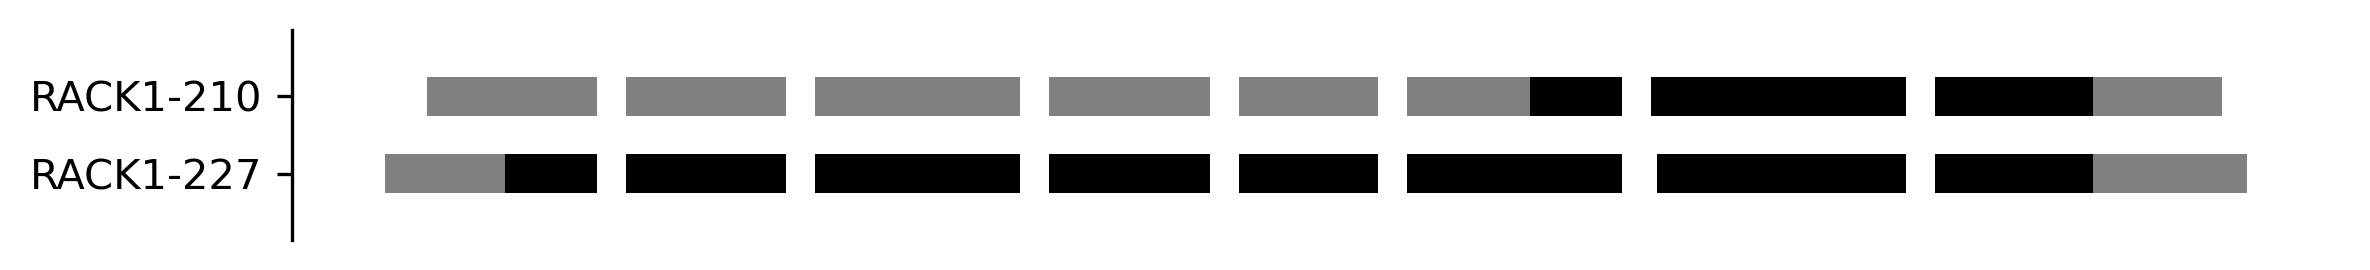

In [211]:
exon_height = 0.5

plot_df['tx_num'] = plot_df['transcript_name'].str.extract(r'-(\d+)$').astype(int)
plot_df = plot_df.sort_values('tx_num')
transcripts = plot_df['transcript_name'].unique()

plot_df = plot_df.sort_values(['tx_num', 'Start'])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 8, len(transcripts)*0.5

fig, ax = plt.subplots()


for i, transcript in enumerate(transcripts):
    tdf = plot_df[plot_df['transcript_name'] == transcript]
    y = i
    for _, row in tdf.iterrows():
        color = 'black' if row['Feature']=='CDS' else 'grey' if row['Feature']=='UTR' else 'white'
        # color = 'grey' if row['Feature'] == 'UTR' else 'black'
        rect = patches.Rectangle(
            (row['collapsed_start'], y - exon_height / 2),
            row['collapsed_end'] - row['collapsed_start'],
            exon_height,
            linewidth=0,
            # edgecolor='black',
            facecolor=color,
            zorder=10,
        )
        ax.add_patch(rect)

# Format
ax.set_yticks(range(len(transcripts)))
ax.set_yticklabels(transcripts)
ax.invert_yaxis()

ax.set_xticks([])
ax.set_xlabel('')
ax.set_facecolor('none')


# plt.grid(axis='y', zorder=0)
plt.margins(y=0.4, x=0.05)
sns.despine(bottom=True)
plt.tight_layout()
fig = plt.gcf()
fig.set_facecolor('none')
plt.show()

In [61]:
# # -----------------------------
# # Step 2: Truncate UTRs
# # -----------------------------
# def truncate_and_align_utrs(df, n_keep_start=1000):
#     """
#     Truncate long UTRs and align ends across transcripts.
#     The middle truncated region will be collapsed later.
#     """
#     df = df.copy()
    
#     utrs = df[df['Feature'] == 'UTR']
#     if utrs.empty:
#         return df

#     # Find the shortest UTR end
#     utr_shortest_end = utrs['End'].min()
    
#     new_rows = []
#     for _, row in df.iterrows():
#         start, end, feature = row['Start'], row['End'], row['Feature']

#         if feature != 'UTR' or (end - start) <= n_keep_start * 2:
#             new_rows.append(row)
#         else:
#             # Keep first part
#             row_start = row.copy()
#             row_start['Start'] = start
#             row_start['End'] = start + n_keep_start

#             # Keep last part aligned to shortest UTR end
#             row_end = row.copy()
#             row_end['Start'] = utr_shortest_end - n_keep_start
#             row_end['End'] = row_end['Start'] + n_keep_start

#             new_rows.extend([row_start, row_end])
    
#     return pd.DataFrame(new_rows)

# df = truncate_and_align_utrs(df, n_keep_start=1000)

# # -----------------------------
# # Step 3: Merge intervals and compute collapsed coordinates
# # -----------------------------
# gap = 10  # spacing between merged intervals
# utr_gap = 1000  # fixed length of collapsed middle region

# intervals = df[['Chromosome', 'Start', 'End']].sort_values('Start').reset_index(drop=True)

# merged_rows = []
# current_start = None
# current_end = None
# chrom = None

# for _, row in intervals.iterrows():
#     if current_start is None:
#         chrom = row['Chromosome']
#         current_start = row['Start']
#         current_end = row['End']
#         continue

#     if row['Start'] <= current_end:
#         current_end = max(current_end, row['End'])
#     else:
#         merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
#         current_start = row['Start']
#         current_end = row['End']

# merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})

# merged_df = pd.DataFrame(merged_rows)

# # Assign collapsed coordinates
# collapsed_positions = []
# collapsed_current = 0

# for _, row in merged_df.iterrows():
#     # Check if interval contains a truncated UTR
#     contains_utr = df[(df['Start'] == row['Start']) & (df['Feature'] == 'UTR')]
#     length = row['End'] - row['Start']
#     if not contains_utr.empty:
#         length = utr_gap  # collapse middle region to fixed size

#     row['collapsed_start'] = collapsed_current
#     row['collapsed_end'] = collapsed_current + length
#     collapsed_current += length + gap
#     collapsed_positions.append(row)

# merged_df = pd.DataFrame(collapsed_positions)

# # -----------------------------
# # Step 4: Map exons to collapsed coordinates
# # -----------------------------
# # def map_exon(row, merged_df):
# #     hit = merged_df[(merged_df['Start'] <= row['Start']) & (merged_df['End'] >= row['End'])]
# #     if hit.empty:
# #         # Sometimes start or end may not exactly match: take nearest interval
# #         hit = merged_df.iloc[(merged_df['Start'] - row['Start']).abs().argmin()]
    
# #     offset = row['Start'] - hit['Start']
# #     return pd.Series({
# #         'collapsed_start': hit['collapsed_start'] + offset,
# #         'collapsed_end': hit['collapsed_start'] + offset + (row['End'] - row['Start'])
# #     })

# def map_exon_safe(row, merged_df, utr_gap=1000):
#     """
#     Map a single exon to collapsed coordinates safely.
#     Handles truncated UTRs with fixed gap.
#     """
#     # Find containing merged interval
#     hit = merged_df[(merged_df['Start'] <= row['Start']) & (merged_df['End'] >= row['End'])]

#     if hit.empty:
#         # fallback: nearest interval
#         hit = merged_df.iloc[(merged_df['Start'] - row['Start']).abs().argmin(): (merged_df['Start'] - row['Start']).abs().argmin()+1]
#     else:
#         # pick the first row if multiple intervals match
#         hit = hit.iloc[[0]]

#     # hit is now a single-row DataFrame
#     hit_start = int(hit['collapsed_start'].values[0])

#     offset = int(row['Start'] - hit['Start'].values[0])

#     # If this is a UTR second segment, start after utr_gap
#     if row['Feature'] == 'UTR' and offset > 0:
#         collapsed_start = hit_start + utr_gap
#     else:
#         collapsed_start = hit_start + offset

#     collapsed_end = collapsed_start + int(row['End'] - row['Start'])

#     return pd.Series({'collapsed_start': collapsed_start, 'collapsed_end': collapsed_end})

# # df[['collapsed_start', 'collapsed_end']] = df.apply(map_exon, axis=1, merged_df=merged_df)

# df[['collapsed_start', 'collapsed_end']] = df.apply(
#     map_exon_safe, axis=1, merged_df=merged_df, utr_gap=utr_gap
# )

# display(df)

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
1757679,TEAD1-203,chr11,12879442,12879665,UTR,ENSE00002144916,1.0,3178,3401
1757662,TEAD1-203,chr11,12879665,12879842,CDS,ENSE00002144916,1.0,3401,3578
1757665,TEAD1-203,chr11,12881004,12881051,CDS,ENSE00000890040,1.0,4188,4235
1757667,TEAD1-203,chr11,12881895,12881957,CDS,ENSE00000890041,1.0,4245,4307
1757669,TEAD1-203,chr11,12883000,12883125,CDS,ENSE00001260349,1.0,4317,4442
1757671,TEAD1-203,chr11,12901939,12902113,CDS,ENSE00001260398,1.0,4452,4626
1757673,TEAD1-203,chr11,12924911,12925052,CDS,ENSE00001101315,1.0,4636,4777
1757675,TEAD1-203,chr11,12930173,12930326,CDS,ENSE00001101300,1.0,4787,4940
1757677,TEAD1-203,chr11,12937108,12937219,CDS,ENSE00002175034,1.0,4950,5061
1757680,TEAD1-203,chr11,12937219,12938219,UTR,ENSE00002175034,1.0,5950,6950


In [46]:
# # Step 1: Subset and filter your GTF
# query = [
#     'TEAD1-203', 
#     'TEAD1-206',
# ]
# columns = ['transcript_name', 'Chromosome', 'Start', 'End', 'Feature', 'exon_id', 'exon_version']

# df = gtf[gtf['transcript_name'].isin(query)].copy()
# df = df[df['Feature'].isin(['CDS', 'UTR'])]
# df = df[columns]

# print(f"{df.shape=}")

# # Sort by transcript and exon number
# df = df.sort_values(["transcript_name", "Start"])
# print(df.head(10).to_string(index=False))


# # Step 2: Truncate UTRs
# def truncate_and_synchronize_utrs(df, utr_start_keep=1000):
#     df = df.copy()
#     utrs = df[df['Feature'] == 'UTR']
#     if utrs.empty:
#         return df

#     utr_shortest_end = utrs['End'].min()
#     new_rows = []

#     for _, row in df.iterrows():
#         start, end, feature = row['Start'], row['End'], row['Feature']

#         if feature != 'UTR' or (end - start) <= utr_start_keep:
#             new_rows.append(row)
#         else:
#             # Keep first utr_start_keep nts
#             row1 = row.copy()
#             row1['Start'] = start
#             row1['End'] = start + utr_start_keep

#             # Keep last utr_start_keep nts aligned to shortest UTR end
#             row2 = row.copy()
#             row2['Start'] = utr_shortest_end - utr_start_keep
#             row2['End'] = utr_shortest_end

#             new_rows.extend([row1, row2])

#     return pd.DataFrame(new_rows)

# df = truncate_and_synchronize_utrs(df, utr_start_keep=1000)
# display(df)

df.shape=(25, 7)
transcript_name Chromosome    Start      End Feature         exon_id  exon_version
      TEAD1-203      chr11 12879442 12879665     UTR ENSE00002144916           1.0
      TEAD1-203      chr11 12879665 12879842     CDS ENSE00002144916           1.0
      TEAD1-203      chr11 12881004 12881051     CDS ENSE00000890040           1.0
      TEAD1-203      chr11 12881895 12881957     CDS ENSE00000890041           1.0
      TEAD1-203      chr11 12883000 12883125     CDS ENSE00001260349           1.0
      TEAD1-203      chr11 12901939 12902113     CDS ENSE00001260398           1.0
      TEAD1-203      chr11 12924911 12925052     CDS ENSE00001101315           1.0
      TEAD1-203      chr11 12930173 12930326     CDS ENSE00001101300           1.0
      TEAD1-203      chr11 12937108 12937219     CDS ENSE00002175034           1.0
      TEAD1-203      chr11 12937219 12944483     UTR ENSE00002175034           1.0


,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version
1757679,TEAD1-203,chr11,12879442,12879665,UTR,ENSE00002144916,1.0
1757662,TEAD1-203,chr11,12879665,12879842,CDS,ENSE00002144916,1.0
1757665,TEAD1-203,chr11,12881004,12881051,CDS,ENSE00000890040,1.0
1757667,TEAD1-203,chr11,12881895,12881957,CDS,ENSE00000890041,1.0
1757669,TEAD1-203,chr11,12883000,12883125,CDS,ENSE00001260349,1.0
1757671,TEAD1-203,chr11,12901939,12902113,CDS,ENSE00001260398,1.0
1757673,TEAD1-203,chr11,12924911,12925052,CDS,ENSE00001101315,1.0
1757675,TEAD1-203,chr11,12930173,12930326,CDS,ENSE00001101300,1.0
1757677,TEAD1-203,chr11,12937108,12937219,CDS,ENSE00002175034,1.0
1757680,TEAD1-203,chr11,12937219,12938219,UTR,ENSE00002175034,1.0


In [47]:
# # Step 3: Merge intervals after truncation
# intervals = df[['Chromosome', 'Start', 'End']].sort_values('Start').reset_index(drop=True)

# merged_rows = []
# current_start = None
# current_end = None
# chrom = None

# for _, row in intervals.iterrows():
#     if current_start is None:
#         chrom = row['Chromosome']
#         current_start = row['Start']
#         current_end = row['End']
#         continue

#     if row['Start'] <= current_end:  # overlap
#         current_end = max(current_end, row['End'])
#     else:
#         merged_rows.append({
#             'Chromosome': chrom,
#             'Start': current_start,
#             'End': current_end
#         })
#         current_start = row['Start']
#         current_end = row['End']

# merged_rows.append({
#     'Chromosome': chrom,
#     'Start': current_start,
#     'End': current_end
# })

# merged_df = pd.DataFrame(merged_rows)
# # Assign collapsed coordinates
# merged_df['collapsed_start'] = range(0, len(merged_df)*1000, 1000)
# merged_df['collapsed_end'] = merged_df['collapsed_start'] + (merged_df['End'] - merged_df['Start'])

# # Step 4: Map exons to collapsed coordinates
# def map_exon(row, merged_df):
#     hit = merged_df[
#         (merged_df['Start'] <= row['Start']) &
#         (merged_df['End'] >= row['End'])
#     ]
#     if hit.empty:
#         raise ValueError(f"Exon not contained in any merged interval: {row}")

#     hit = hit.iloc[0]
#     offset = row['Start'] - hit['Start']

#     return pd.Series({
#         'collapsed_start': hit['collapsed_start'] + offset,
#         'collapsed_end': hit['collapsed_start'] + offset + (row['End'] - row['Start'])
#     })

# df[['collapsed_start', 'collapsed_end']] = df.apply(map_exon, axis=1, merged_df=merged_df)

# display(df)
# display(merged_df)

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
1757679,TEAD1-203,chr11,12879442,12879665,UTR,ENSE00002144916,1.0,5000,5223
1757662,TEAD1-203,chr11,12879665,12879842,CDS,ENSE00002144916,1.0,5223,5400
1757665,TEAD1-203,chr11,12881004,12881051,CDS,ENSE00000890040,1.0,6000,6047
1757667,TEAD1-203,chr11,12881895,12881957,CDS,ENSE00000890041,1.0,7000,7062
1757669,TEAD1-203,chr11,12883000,12883125,CDS,ENSE00001260349,1.0,8000,8125
1757671,TEAD1-203,chr11,12901939,12902113,CDS,ENSE00001260398,1.0,9000,9174
1757673,TEAD1-203,chr11,12924911,12925052,CDS,ENSE00001101315,1.0,10000,10141
1757675,TEAD1-203,chr11,12930173,12930326,CDS,ENSE00001101300,1.0,11000,11153
1757677,TEAD1-203,chr11,12937108,12937219,CDS,ENSE00002175034,1.0,12000,12111
1757680,TEAD1-203,chr11,12937219,12938219,UTR,ENSE00002175034,1.0,12111,13111


,Chromosome,Start,End,collapsed_start,collapsed_end
0,chr11,12673834,12674834,0,1000
1,chr11,12675408,12675561,1000,1153
2,chr11,12764178,12764434,2000,2256
3,chr11,12862249,12862314,3000,3065
4,chr11,12864837,12864900,4000,4063
5,chr11,12879442,12879842,5000,5400
6,chr11,12881004,12881051,6000,6047
7,chr11,12881895,12881957,7000,7062
8,chr11,12883000,12883125,8000,8125
9,chr11,12901939,12902113,9000,9174


In [50]:
# # Assume df contains only exons from one chromosome
# intervals = (
#     df[['Chromosome', 'Start', 'End']]
#     .sort_values('Start')
#     .reset_index(drop=True)
# )

# merged_rows = []
# current_start = None
# current_end = None
# chrom = None

# for _, row in intervals.iterrows():
#     if current_start is None:
#         chrom = row['Chromosome']
#         current_start = row['Start']
#         current_end = row['End']
#         continue

#     if row['Start'] <= current_end:  # overlap
#         current_end = max(current_end, row['End'])
#     else:
#         merged_rows.append({
#             'Chromosome': chrom,
#             'Start': current_start,
#             'End': current_end
#         })
#         current_start = row['Start']
#         current_end = row['End']

# # append last block
# merged_rows.append({
#     'Chromosome': chrom,
#     'Start': current_start,
#     'End': current_end
# })

# merged_df = pd.DataFrame(merged_rows)
# merged_df.head()

,Chromosome,Start,End
0,chr11,12674420,12674834
1,chr11,12675408,12675561
2,chr11,12764178,12764434
3,chr11,12862249,12862314
4,chr11,12864837,12864900


In [51]:
# gap = 10

# merged_df = merged_df.sort_values('Start').reset_index(drop=True)
# merged_df['Length'] = merged_df['End'] - merged_df['Start']

# merged_df['collapsed_start'] = (
#     merged_df['Length'].shift(fill_value=0).cumsum()
#     + gap * merged_df.index
# )
# merged_df['collapsed_end'] = (
#     merged_df['collapsed_start'] + merged_df['Length']
# )

# display(merged_df)

# # def map_exon(row, merged_df):
# #     hit = merged_df[
# #         (merged_df['Start'] <= row['Start']) &
# #         (merged_df['End'] >= row['End'])
# #     ]

# #     if hit.empty:
# #         raise ValueError("Exon not contained in any merged interval")

# #     hit = hit.iloc[0]
# #     offset = row['Start'] - hit['Start']

# #     return pd.Series({
# #         'collapsed_start': hit['collapsed_start'] + offset,
# #         'collapsed_end': hit['collapsed_start'] + offset + (row['End'] - row['Start'])
# #     })


# # df[['collapsed_start', 'collapsed_end']] = df.apply(
# #     map_exon, axis=1, merged_df=merged_df
# # )

# # display(df)

,Chromosome,Start,End,Length,collapsed_start,collapsed_end
0,chr11,12674420,12674834,414,0,414
1,chr11,12675408,12675561,153,424,577
2,chr11,12764178,12764434,256,587,843
3,chr11,12862249,12862314,65,853,918
4,chr11,12864837,12864900,63,928,991
5,chr11,12879442,12879842,400,1001,1401
6,chr11,12881004,12881051,47,1411,1458
7,chr11,12881895,12881957,62,1468,1530
8,chr11,12883000,12883125,125,1540,1665
9,chr11,12901939,12902113,174,1675,1849


In [52]:
# def truncate_utr(df, utr_gap=1000, n_keep_start=1000, n_keep_end=1000):
#     """
#     Truncate long UTRs for visualization.
    
#     df: dataframe with columns Start, End, Feature
#     utr_gap: artificial gap to insert in the middle
#     n_keep_start: length of UTR to keep at start
#     n_keep_end: length of UTR to keep at end
#     """
#     new_rows = []
    
#     for _, row in df.iterrows():
#         start, end, feature = row['Start'], row['End'], row['Feature']
#         if feature != 'UTR' or (end - start) <= (n_keep_start + n_keep_end):
#             # keep as-is
#             new_rows.append(row)
#         else:
#             # truncate UTR
#             start1 = start
#             end1 = start + n_keep_start
            
#             start2 = end - n_keep_end
#             end2 = end
            
#             # create two “exons” with a gap in between
#             row1 = row.copy()
#             row1['Start'] = start1
#             row1['End'] = end1
            
#             row2 = row.copy()
#             row2['Start'] = start2
#             row2['End'] = end2
            
#             new_rows.extend([row1, row2])
    
#     return pd.DataFrame(new_rows)

# # def truncate_and_synchronize_utrs(df, utr_start_keep=1000, gap_length=1000):
# #     """
# #     Truncate long UTRs across transcripts so they align visually.
    
# #     Parameters
# #     ----------
# #     df : pd.DataFrame
# #         Must have columns: Start, End, Feature, transcript_name
# #     utr_start_keep : int
# #         Number of nts to keep at start of each UTR
# #     gap_length : int
# #         Fixed length of the artificial gap for collapsed region
    
# #     Returns
# #     -------
# #     pd.DataFrame
# #         Updated dataframe with truncated UTRs
# #     """
# #     df = df.copy()
    
# #     # Identify all UTRs
# #     utrs = df[df['Feature'] == 'UTR']
    
# #     if utrs.empty:
# #         return df  # nothing to truncate
    
# #     # Find the shortest UTR end position
# #     utr_shortest_end = utrs['End'].min()
    
# #     new_rows = []
    
# #     for _, row in df.iterrows():
# #         start, end, feature = row['Start'], row['End'], row['Feature']
        
# #         if feature != 'UTR' or (end - start) <= utr_start_keep:
# #             # keep non-UTRs and short UTRs as-is
# #             new_rows.append(row)
# #         else:
# #             # Truncate UTR: keep first utr_start_keep nts
# #             start1 = start
# #             end1 = start + utr_start_keep
            
# #             # Keep the last portion aligned across transcripts
# #             start2 = utr_shortest_end - utr_start_keep  # 1000 nts before shortest UTR end
# #             end2 = utr_shortest_end
            
# #             # create two "exons" with artificial gap
# #             row1 = row.copy()
# #             row1['Start'] = start1
# #             row1['End'] = end1
            
# #             row2 = row.copy()
# #             row2['Start'] = start2
# #             row2['End'] = end2
            
# #             new_rows.extend([row1, row2])
    
# #     return pd.DataFrame(new_rows)


# df = truncate_utr(df, utr_gap=1000, n_keep_start=1000, n_keep_end=1000)

# # df = truncate_and_synchronize_utrs(df, utr_start_keep=1000, gap_length=1000)
# display(df)

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version
1757679,TEAD1-203,chr11,12879442,12879665,UTR,ENSE00002144916,1.0
1757662,TEAD1-203,chr11,12879665,12879842,CDS,ENSE00002144916,1.0
1757665,TEAD1-203,chr11,12881004,12881051,CDS,ENSE00000890040,1.0
1757667,TEAD1-203,chr11,12881895,12881957,CDS,ENSE00000890041,1.0
1757669,TEAD1-203,chr11,12883000,12883125,CDS,ENSE00001260349,1.0
1757671,TEAD1-203,chr11,12901939,12902113,CDS,ENSE00001260398,1.0
1757673,TEAD1-203,chr11,12924911,12925052,CDS,ENSE00001101315,1.0
1757675,TEAD1-203,chr11,12930173,12930326,CDS,ENSE00001101300,1.0
1757677,TEAD1-203,chr11,12937108,12937219,CDS,ENSE00002175034,1.0
1757680,TEAD1-203,chr11,12937219,12938219,UTR,ENSE00002175034,1.0


In [53]:
# def map_exon(row, merged_df):
#     hit = merged_df[
#         (merged_df['Start'] <= row['Start']) &
#         (merged_df['End'] >= row['End'])
#     ]

#     if hit.empty:
#         raise ValueError("Exon not contained in any merged interval")

#     hit = hit.iloc[0]
#     offset = row['Start'] - hit['Start']

#     return pd.Series({
#         'collapsed_start': hit['collapsed_start'] + offset,
#         'collapsed_end': hit['collapsed_start'] + offset + (row['End'] - row['Start'])
#     })


# df[['collapsed_start', 'collapsed_end']] = df.apply(
#     map_exon, axis=1, merged_df=merged_df
# )

# display(df)

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
1757679,TEAD1-203,chr11,12879442,12879665,UTR,ENSE00002144916,1.0,1001,1224
1757662,TEAD1-203,chr11,12879665,12879842,CDS,ENSE00002144916,1.0,1224,1401
1757665,TEAD1-203,chr11,12881004,12881051,CDS,ENSE00000890040,1.0,1411,1458
1757667,TEAD1-203,chr11,12881895,12881957,CDS,ENSE00000890041,1.0,1468,1530
1757669,TEAD1-203,chr11,12883000,12883125,CDS,ENSE00001260349,1.0,1540,1665
1757671,TEAD1-203,chr11,12901939,12902113,CDS,ENSE00001260398,1.0,1675,1849
1757673,TEAD1-203,chr11,12924911,12925052,CDS,ENSE00001101315,1.0,1859,2000
1757675,TEAD1-203,chr11,12930173,12930326,CDS,ENSE00001101300,1.0,2010,2163
1757677,TEAD1-203,chr11,12937108,12937219,CDS,ENSE00002175034,1.0,2173,2284
1757680,TEAD1-203,chr11,12937219,12938219,UTR,ENSE00002175034,1.0,2284,3284


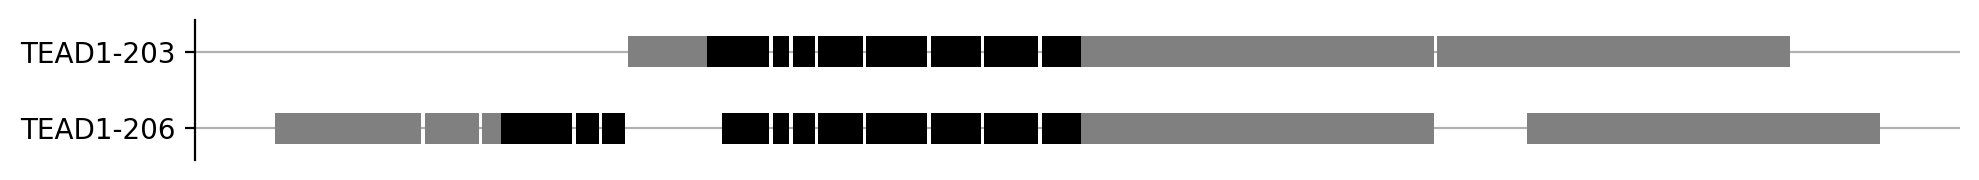

In [73]:
# # Plotting
# # plt.rcParams['figure.dpi'] = 200
# # plt.rcParams['figure.figsize'] = 10, 1.1

# # fig, ax = plt.subplots()
# exon_height = 0.4

# df['tx_num'] = df['transcript_name'].str.extract(r'-(\d+)$').astype(int)
# df = df.sort_values('tx_num')
# transcripts = df['transcript_name'].unique()

# df = df.sort_values(['tx_num', 'Start'])

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 10, len(transcripts)*0.5

# fig, ax = plt.subplots()


# for i, transcript in enumerate(transcripts):
#     tdf = df[df['transcript_name'] == transcript]
#     y = i
#     for _, row in tdf.iterrows():
#         color = 'grey' if row['Feature'] == 'UTR' else 'black'
#         rect = patches.Rectangle(
#             (row['collapsed_start'], y - exon_height / 2),
#             row['collapsed_end'] - row['collapsed_start'],
#             exon_height,
#             linewidth=0,
#             # edgecolor='black',
#             facecolor=color,
#             zorder=10,
#         )
#         ax.add_patch(rect)

# # Format
# ax.set_yticks(range(len(transcripts)))
# ax.set_yticklabels(transcripts)
# ax.invert_yaxis()

# ax.set_xticks([])
# ax.set_xlabel('')
# ax.set_facecolor('none')

# # ax.set_xlim([0, 4000])


# plt.grid(axis='y', zorder=0)
# plt.margins(y=0.15, x=0.05)
# sns.despine(bottom=True)
# plt.tight_layout()
# fig = plt.gcf()
# fig.set_facecolor('none')
# plt.show()

In [8]:
transcripts

array(['TEAD1-206', 'TEAD1-203'], dtype=object)